# 04 — Ablation Study, Feature Importance & Final Analysis

Loads the tuned candidate pipelines saved by Notebook 03 (no re-tuning from scratch).
Performs class-weight comparison, SMOTE comparison, ablation, training-size experiments
(stratified subsampling), feature importance, multi-seed robustness, and statistical tests.


In [23]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

In [24]:
import pandas as pd
from sklearn.base import clone

from src.config import (
    get_project_paths, ROBUSTNESS_SEEDS,
    DEMOGRAPHIC_FEATURES, BILIRUBIN_FEATURES, ENZYME_FEATURES, PROTEIN_FEATURES,
)
from src.data import (
    load_processed_dataset, prepare_binary_target,
    split_features_target, create_train_test_split,
)
from src.preprocessing import create_preprocessor
from src.models import get_class_weighted_variants
from src.evaluation import (
    make_eval_cv_splits,
    run_cross_validation,
    run_test_evaluation,
    add_selection_score,
    load_candidate_models,
    run_seed_robustness,
)
from src.experiments import (
    run_class_weight_comparison,
    run_smote_comparison,
    run_ablation_study,
    run_training_size_experiment,
)
from src.plots import (
    save_metric_bar_plot,
    save_confusion_matrices,
    save_learning_curve_plot,
    save_pvalue_heatmap,
)
from src.feature_analysis import (
    get_logistic_regression_coefficients,
    get_random_forest_feature_importance,
    get_permutation_importance,
    save_feature_importance_plot,
    get_misclassified_examples,
)
from src.stats import (
    run_wilcoxon_pairwise,
    run_mcnemar_pairwise,
)

## 1. Load data (same split as NB03)

In [25]:
paths = get_project_paths()
tables_dir  = paths["tables_dir"]
figures_dir = paths["figures_dir"]
models_dir  = paths["models_dir"]

df = load_processed_dataset(paths["processed_data_path"])
df_model = prepare_binary_target(df)
X, y = split_features_target(df_model)

# Same random_state=42 → identical split to NB03
X_train, X_test, y_train, y_test = create_train_test_split(X, y)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (456, 10) | Test: (114, 10)


## 2. Load tuned candidate models from NB03 (no re-tuning)

In [26]:
# FIXED: candidate models carry the best hyperparameters found in NB03.
# We do NOT tune again — avoids inconsistent results between notebooks.
candidate_pipelines = load_candidate_models(models_dir)
candidate_names = list(candidate_pipelines.keys())
print("Candidates:", candidate_names)

Candidate models loaded from C:\lfd_project\results\models\candidate_models.pkl
Candidates: ['Gradient Boosting', 'Random Forest']


## 3. Preprocessor and eval CV splits

In [27]:
preprocessor, numeric_features, categorical_features = create_preprocessor(X_train)

# Fresh eval CV splits for NB04 (same design, independent list)
eval_cv_splits = make_eval_cv_splits(X_train, y_train, random_state=42)
print("Eval CV splits:", len(eval_cv_splits))

Eval CV splits: 10


## 4. Candidate 5×2 CV evaluation

In [28]:
cv_df, raw_cv_scores = run_cross_validation(
    estimators=candidate_pipelines,
    X_train=X_train,
    y_train=y_train,
    eval_cv_splits=eval_cv_splits,
)
cv_df = add_selection_score(cv_df)
cv_df.to_csv(tables_dir / "nb04_candidate_cv.csv", index=False)
cv_df.round(4)

5×2 CV evaluation: Gradient Boosting
5×2 CV evaluation: Random Forest


,Model,CV Accuracy Mean,CV Accuracy Std,CV Balanced Accuracy Mean,CV Balanced Accuracy Std,CV Precision Mean,CV Precision Std,CV Recall Mean,CV Recall Std,CV F1 Mean,CV F1 Std,CV Roc Auc Mean,CV Roc Auc Std,CV Average Precision Mean,CV Average Precision Std,CV Mcc Mean,CV Mcc Std,Selection Score
0,Gradient Boosting,0.6772,0.0160,0.5777,0.0203,0.7547,0.0140,0.8117,0.0378,0.7815,0.0152,0.6739,0.0240,0.8413,0.0163,0.1667,0.0360,0.7112
1,Random Forest,0.6750,0.0243,0.6476,0.0154,0.8099,0.0139,0.7120,0.0528,0.7564,0.0271,0.7154,0.0269,0.8716,0.0186,0.2781,0.0279,0.7079


## 5. Candidate test-set evaluation

Test evaluation: Gradient Boosting
              precision    recall  f1-score   support

           0       0.62      0.15      0.24        33
           1       0.74      0.96      0.83        81

    accuracy                           0.73       114
   macro avg       0.68      0.56      0.54       114
weighted avg       0.70      0.73      0.66       114

Confusion Matrix:
 [[ 5 28]
 [ 3 78]]
Test evaluation: Random Forest
              precision    recall  f1-score   support

           0       0.52      0.76      0.62        33
           1       0.88      0.72      0.79        81

    accuracy                           0.73       114
   macro avg       0.70      0.74      0.70       114
weighted avg       0.78      0.73      0.74       114

Confusion Matrix:
 [[25  8]
 [23 58]]


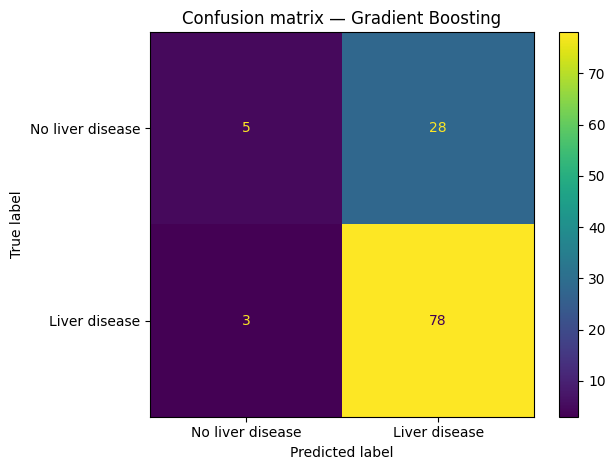

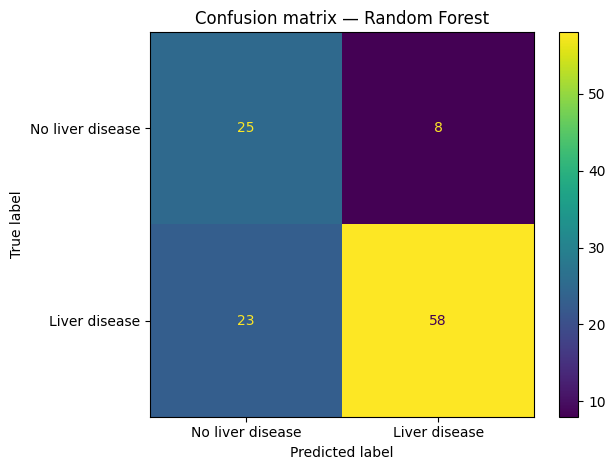

,Model,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,MCC,TN,FP,FN,TP,ROC-AUC,PR-AUC,Training Time (s),Inference Time (s),Selection Score
0,Gradient Boosting,0.7281,0.5572,0.7358,0.963,0.1515,0.8342,0.2032,5,28,3,78,0.7475,0.9008,0.2367,0.0032,0.7755
1,Random Forest,0.7281,0.7368,0.8788,0.716,0.7576,0.7891,0.4351,25,8,23,58,0.8137,0.9238,0.1856,0.0070,0.7639


In [29]:
test_df, trained_candidates, predictions = run_test_evaluation(
    estimators=candidate_pipelines,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
)
test_df = add_selection_score(test_df)
test_df.to_csv(tables_dir / "nb04_candidate_test.csv", index=False)
save_confusion_matrices(trained_candidates, X_test, y_test, figures_dir)
test_df.round(4)

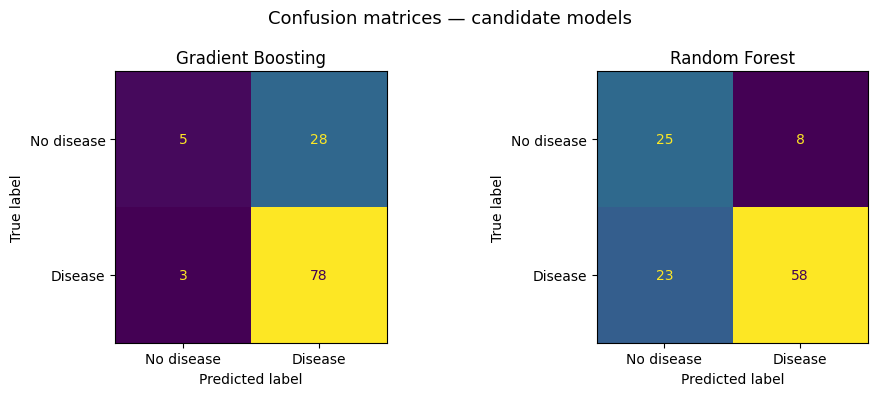

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (model_name, model) in zip(axes, trained_candidates.items()):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["No disease", "Disease"],
        ax=ax,
        colorbar=False,
    )
    ax.set_title(model_name)

plt.suptitle("Confusion matrices — candidate models", fontsize=13)
plt.tight_layout()
plt.savefig(figures_dir / "confusion_matrix_candidates_side_by_side.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 6. Statistical tests — candidates only

In [30]:
wilcoxon_cand = run_wilcoxon_pairwise(raw_cv_scores, metric="recall")
wilcoxon_cand.to_csv(tables_dir / "nb04_wilcoxon_candidates.csv", index=False)
print("Wilcoxon (recall, candidates):")
print(wilcoxon_cand.round(4).to_string(index=False))

Wilcoxon (recall, candidates):
          Model A       Model B Metric  Mean A  Mean B  W Statistic  p-value  Significant (α=0.05)
Gradient Boosting Random Forest recall  0.8117   0.712          0.0    0.002                  True


In [31]:
mcnemar_cand = run_mcnemar_pairwise(predictions, y_test)
mcnemar_cand.to_csv(tables_dir / "nb04_mcnemar_candidates.csv", index=False)
print("McNemar (candidates):")
print(mcnemar_cand.round(4).to_string(index=False))

McNemar (candidates):
          Model A       Model B  b (A wrong, B right)  c (A right, B wrong)   Chi2  p-value  Significant (α=0.05)
Gradient Boosting Random Forest                    22                    22 0.0227   0.8802                 False


## 7. Class-weighted training comparison

In [32]:
candidate_classifiers = {
    name: candidate_pipelines[name].named_steps["classifier"]
    for name in candidate_names
}

# Also include the class-weighted variants in the same comparison
all_cw_models = {
    **candidate_classifiers,
    **get_class_weighted_variants(candidate_names),
}

cw_results, _, cw_preds = run_class_weight_comparison(
    model_variants=all_cw_models,
    preprocessor=preprocessor,
    X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
)
cw_results = add_selection_score(cw_results)
cw_results.to_csv(tables_dir / "nb04_class_weight_comparison.csv", index=False)
cw_results.round(4)

Test evaluation: Gradient Boosting
              precision    recall  f1-score   support

           0       0.62      0.15      0.24        33
           1       0.74      0.96      0.83        81

    accuracy                           0.73       114
   macro avg       0.68      0.56      0.54       114
weighted avg       0.70      0.73      0.66       114

Confusion Matrix:
 [[ 5 28]
 [ 3 78]]
Test evaluation: Random Forest
              precision    recall  f1-score   support

           0       0.52      0.76      0.62        33
           1       0.88      0.72      0.79        81

    accuracy                           0.73       114
   macro avg       0.70      0.74      0.70       114
weighted avg       0.78      0.73      0.74       114

Confusion Matrix:
 [[25  8]
 [23 58]]
Test evaluation: Gradient Boosting (balanced)
              precision    recall  f1-score   support

           0       0.56      0.15      0.24        33
           1       0.73      0.95      0.83      

,Model,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,MCC,TN,FP,FN,TP,ROC-AUC,PR-AUC,Training Time (s),Inference Time (s),Selection Score
0,Gradient Boosting,0.7281,0.5572,0.7358,0.9630,0.1515,0.8342,0.2032,5,28,3,78,0.7475,0.9008,0.2236,0.0028,0.7755
1,Random Forest,0.7281,0.7368,0.8788,0.7160,0.7576,0.7891,0.4351,25,8,23,58,0.8137,0.9238,0.1830,0.0074,0.7639
2,Gradient Boosting (balanced),0.7193,0.5511,0.7333,0.9506,0.1515,0.8280,0.1718,5,28,4,77,0.7561,0.9062,0.1003,0.0026,0.7714
3,Random Forest (balanced),0.7368,0.5903,0.7525,0.9383,0.2424,0.8352,0.2578,8,25,5,76,0.7767,0.8966,0.1089,0.0054,0.7851


## 8. SMOTE comparison

In [33]:
smote_results, _, _ = run_smote_comparison(
    models=candidate_classifiers,
    preprocessor=preprocessor,
    X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
)
if "Model" in smote_results.columns:
    smote_results = add_selection_score(smote_results)
smote_results.to_csv(tables_dir / "nb04_smote_comparison.csv", index=False)
smote_results.round(4)

Test evaluation: Gradient Boosting (no SMOTE)
              precision    recall  f1-score   support

           0       0.62      0.15      0.24        33
           1       0.74      0.96      0.83        81

    accuracy                           0.73       114
   macro avg       0.68      0.56      0.54       114
weighted avg       0.70      0.73      0.66       114

Confusion Matrix:
 [[ 5 28]
 [ 3 78]]
Test evaluation: Gradient Boosting (SMOTE)
              precision    recall  f1-score   support

           0       0.59      0.30      0.40        33
           1       0.76      0.91      0.83        81

    accuracy                           0.74       114
   macro avg       0.68      0.61      0.62       114
weighted avg       0.71      0.74      0.71       114

Confusion Matrix:
 [[10 23]
 [ 7 74]]
Test evaluation: Random Forest (no SMOTE)
              precision    recall  f1-score   support

           0       0.52      0.76      0.62        33
           1       0.88      0

,Model,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,MCC,TN,FP,FN,TP,ROC-AUC,PR-AUC,Training Time (s),Inference Time (s),Selection Score
0,Gradient Boosting (no SMOTE),0.7281,0.5572,0.7358,0.9630,0.1515,0.8342,0.2032,5,28,3,78,0.7475,0.9008,0.2016,0.0031,0.7755
1,Gradient Boosting (SMOTE),0.7368,0.6083,0.7629,0.9136,0.3030,0.8315,0.2758,10,23,7,74,0.7718,0.9016,0.2950,0.0033,0.7813
2,Random Forest (no SMOTE),0.7281,0.7368,0.8788,0.7160,0.7576,0.7891,0.4351,25,8,23,58,0.8137,0.9238,0.1761,0.0069,0.7639
3,Random Forest (SMOTE),0.7193,0.7217,0.8657,0.7160,0.7273,0.7838,0.4084,24,9,23,58,0.8036,0.9184,0.2035,0.0073,0.7563


## 9. Ablation study

Controlled experiments removing one feature group at a time.
Shows contribution of demographic vs biochemical feature groups.

In [34]:
ablation_sets = {
    "All features": [],
    "Without Age": ["Age"],
    "Without Gender": ["Gender"],
    "Without demographics": DEMOGRAPHIC_FEATURES,
    "Without bilirubin": BILIRUBIN_FEATURES,
    "Without enzymes": ENZYME_FEATURES,
    "Without protein features": PROTEIN_FEATURES,
}

ablation_df = run_ablation_study(
    models=candidate_classifiers,
    preprocessor_factory=create_preprocessor,
    X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
    ablation_sets=ablation_sets,
)
ablation_df = add_selection_score(ablation_df)
ablation_df.to_csv(tables_dir / "nb04_ablation.csv", index=False)
ablation_df.round(4)

Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest


,Model,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,MCC,TN,FP,FN,TP,ROC-AUC,PR-AUC,Training Time (s),Inference Time (s),Ablation Setting,Removed Features,Selection Score
0,Gradient Boosting,0.7281,0.5572,0.7358,0.9630,0.1515,0.8342,0.2032,5,28,3,78,0.7475,0.9008,0.1910,0.0046,All features,None,0.7755
1,Random Forest,0.7281,0.7368,0.8788,0.7160,0.7576,0.7891,0.4351,25,8,23,58,0.8137,0.9238,0.1838,0.0080,All features,None,0.7639
2,Gradient Boosting,0.6579,0.4809,0.7019,0.9012,0.0606,0.7892,-0.0612,2,31,8,73,0.6790,0.8713,0.1918,0.0029,Without Age,Age,0.7126
3,Random Forest,0.6930,0.6942,0.8485,0.6914,0.6970,0.7619,0.3567,23,10,25,56,0.7946,0.9126,0.1973,0.0098,Without Age,Age,0.7355
4,Gradient Boosting,0.7105,0.5539,0.7353,0.9259,0.1818,0.8197,0.1592,6,27,6,75,0.7426,0.8965,0.1963,0.0018,Without Gender,Gender,0.7605
5,Random Forest,0.7368,0.7520,0.8923,0.7160,0.7879,0.7945,0.4617,26,7,23,58,0.8043,0.9196,0.1802,0.0060,Without Gender,Gender,0.7667
6,Gradient Boosting,0.6754,0.5202,0.7200,0.8889,0.1515,0.7956,0.0558,5,28,9,72,0.6768,0.8750,0.2037,0.0022,Without demographics,"Age, Gender",0.7204
7,Random Forest,0.7105,0.7155,0.8636,0.7037,0.7273,0.7755,0.3959,24,9,24,57,0.7961,0.9161,0.1647,0.0058,Without demographics,"Age, Gender",0.7477
8,Gradient Boosting,0.6842,0.5443,0.7320,0.8765,0.2121,0.7978,0.1129,7,26,10,71,0.6955,0.8660,0.2292,0.0032,Without bilirubin,"Total_Bilirubin, Direct_Bilirubin",0.7285
9,Random Forest,0.7193,0.7037,0.8451,0.7407,0.6667,0.7895,0.3812,22,11,21,60,0.7875,0.9075,0.2212,0.0094,Without bilirubin,"Total_Bilirubin, Direct_Bilirubin",0.7554


## 10. Training-size experiment (stratified subsampling)

Trains on 25 / 50 / 75 / 100 % of the training data. Subsets are drawn with
**StratifiedShuffleSplit** to preserve the class ratio at every fraction.

In [35]:
size_df = run_training_size_experiment(
    models=candidate_classifiers,
    preprocessor_factory=create_preprocessor,
    X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test,
    train_fractions=(0.25, 0.50, 0.75, 1.00),
)
size_df = add_selection_score(size_df)
size_df.to_csv(tables_dir / "nb04_training_size.csv", index=False)
size_df.round(4)

Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest


,Model,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,MCC,TN,FP,FN,TP,ROC-AUC,PR-AUC,Training Time (s),Inference Time (s),Training Fraction,Training Size,Selection Score
0,Gradient Boosting,0.7281,0.6291,0.7778,0.8642,0.3939,0.8187,0.2872,13,20,11,70,0.6629,0.8153,0.1200,0.0036,0.25,114,0.7437
1,Random Forest,0.7368,0.6532,0.7931,0.8519,0.4545,0.8214,0.3268,15,18,12,69,0.7419,0.8942,0.1541,0.0078,0.25,114,0.7671
2,Gradient Boosting,0.7368,0.6263,0.7742,0.8889,0.3636,0.8276,0.2954,12,21,9,72,0.7067,0.8383,0.1672,0.0059,0.50,228,0.7624
3,Random Forest,0.7281,0.6829,0.8205,0.7901,0.5758,0.8050,0.3570,19,14,17,64,0.7722,0.9057,0.2112,0.0106,0.50,228,0.7626
4,Gradient Boosting,0.6930,0.5415,0.7300,0.9012,0.1818,0.8066,0.1148,6,27,8,73,0.7430,0.8897,0.1943,0.0034,0.75,342,0.7481
5,Random Forest,0.7193,0.7127,0.8551,0.7284,0.6970,0.7867,0.3947,23,10,22,59,0.8032,0.9175,0.1838,0.0072,0.75,342,0.7577
6,Gradient Boosting,0.7281,0.5572,0.7358,0.9630,0.1515,0.8342,0.2032,5,28,3,78,0.7475,0.9008,0.2251,0.0031,1.00,456,0.7755
7,Random Forest,0.7281,0.7368,0.8788,0.7160,0.7576,0.7891,0.4351,25,8,23,58,0.8137,0.9238,0.1976,0.0082,1.00,456,0.7639


## 11. Learning curves (CV-based, separate from training-size experiment)

Note: learning_curve() uses eval_cv_splits for validation scores. This is presented
to show bias-variance trend — it is a different visualisation from the training-size
ablation above, which used a fixed held-out test set.

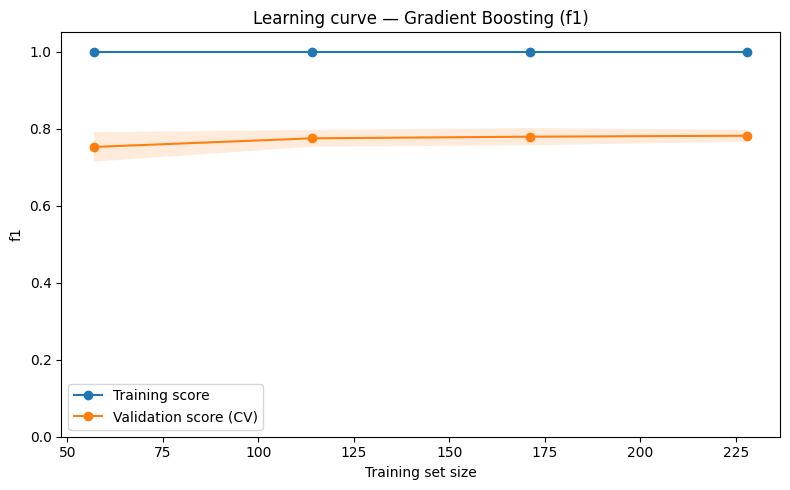

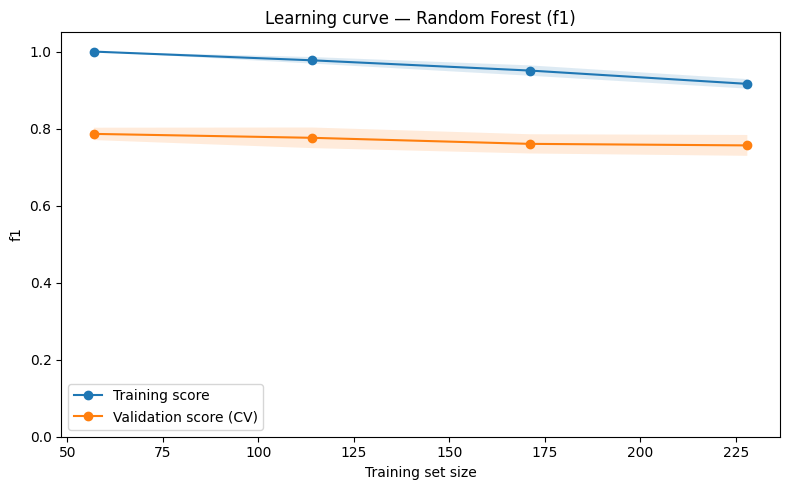

In [36]:
for model_name, estimator in trained_candidates.items():
    save_learning_curve_plot(
        estimator=estimator,
        X=X_train, y=y_train,
        model_name=model_name,
        figures_dir=figures_dir,
        cv_splits=eval_cv_splits,
        scoring="f1",
        train_sizes=(0.25, 0.50, 0.75, 1.00),
    )

## 12. Feature importance

### 12a. Logistic Regression — standardised coefficients

In [37]:
for model_name, model in trained_candidates.items():
    if "Logistic" in model_name or "logistic" in model_name.lower():
        lr_coef = get_logistic_regression_coefficients(
            model, numeric_features, categorical_features,
        )
        lr_coef.to_csv(tables_dir / "nb04_lr_coefficients.csv", index=False)
        save_feature_importance_plot(
            lr_coef, value_col="Absolute Coefficient",
            title=f"Logistic Regression coefficients — {model_name}",
            figures_dir=figures_dir,
            file_name="nb04_lr_coefficients.png",
        )
        print(lr_coef.head(10).to_string(index=False))

### 12b. Random Forest — impurity-based importance

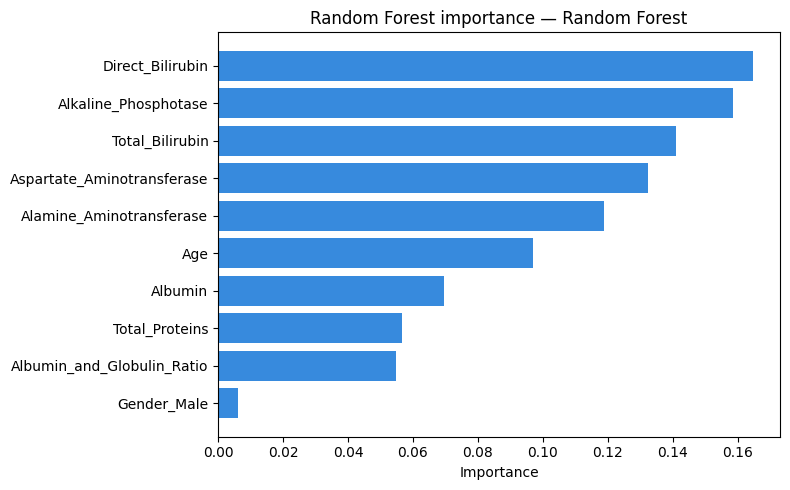

                   Feature  Importance
          Direct_Bilirubin    0.164828
      Alkaline_Phosphotase    0.158540
           Total_Bilirubin    0.141082
Aspartate_Aminotransferase    0.132519
  Alamine_Aminotransferase    0.118919
                       Age    0.096941
                   Albumin    0.069621
            Total_Proteins    0.056543
Albumin_and_Globulin_Ratio    0.054738
               Gender_Male    0.006269


In [38]:
for model_name, model in trained_candidates.items():
    if "Forest" in model_name or "forest" in model_name.lower():
        rf_imp = get_random_forest_feature_importance(
            model, numeric_features, categorical_features,
        )
        rf_imp.to_csv(tables_dir / "nb04_rf_importance.csv", index=False)
        save_feature_importance_plot(
            rf_imp, value_col="Importance",
            title=f"Random Forest importance — {model_name}",
            figures_dir=figures_dir,
            file_name="nb04_rf_importance.png",
        )
        print(rf_imp.head(10).to_string(index=False))

### 12c. Permutation importance (model-agnostic, evaluated on test set)

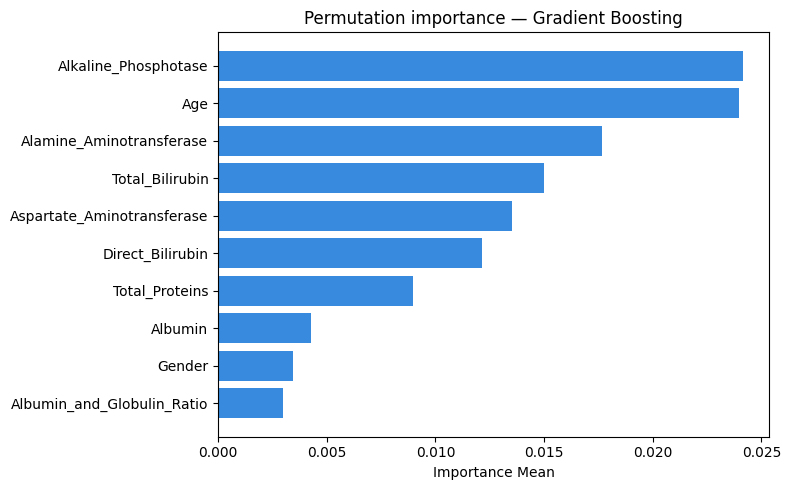


Gradient Boosting:
                   Feature  Importance Mean  Importance Std
      Alkaline_Phosphotase         0.024164        0.007043
                       Age         0.023986        0.011547
  Alamine_Aminotransferase         0.017646        0.012372
           Total_Bilirubin         0.014995        0.006836
Aspartate_Aminotransferase         0.013530        0.011038


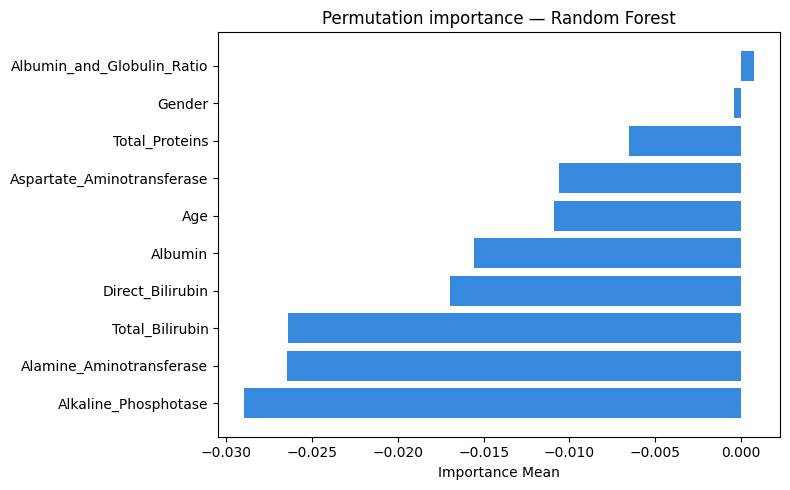


Random Forest:
                   Feature  Importance Mean  Importance Std
Albumin_and_Globulin_Ratio         0.000792        0.006038
                    Gender        -0.000381        0.006094
            Total_Proteins        -0.006550        0.007354
Aspartate_Aminotransferase        -0.010607        0.014478
                       Age        -0.010871        0.009208


In [39]:
for model_name, model in trained_candidates.items():
    perm_df = get_permutation_importance(model, X_test, y_test, scoring="f1")
    safe = model_name.lower().replace(" ", "_")
    perm_df.to_csv(tables_dir / f"nb04_permutation_{safe}.csv", index=False)
    save_feature_importance_plot(
        perm_df, value_col="Importance Mean",
        title=f"Permutation importance — {model_name}",
        figures_dir=figures_dir,
        file_name=f"nb04_permutation_{safe}.png",
    )
    print(f"\n{model_name}:")
    print(perm_df.head(5).to_string(index=False))

## 13. Multi-seed robustness

In [40]:
seed_all, seed_summary = run_seed_robustness(
    models=candidate_classifiers,
    preprocessor_factory=create_preprocessor,
    X=X, y=y,
    seeds=ROBUSTNESS_SEEDS,
)
seed_all.to_csv(tables_dir / "nb04_seed_all.csv", index=False)
seed_summary.to_csv(tables_dir / "nb04_seed_summary.csv", index=False)
print("Robustness summary (mean ± std across seeds):")
seed_summary.round(4)

Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Test evaluation: Gradient Boosting
Test evaluation: Random Forest
Robustness summary (mean ± std across seeds):


,Model,Accuracy mean,Accuracy std,Balanced Accuracy mean,Balanced Accuracy std,Precision mean,Precision std,Recall mean,Recall std,Specificity mean,...,ROC-AUC mean,ROC-AUC std,PR-AUC mean,PR-AUC std,Training Time (s) mean,Training Time (s) std,Inference Time (s) mean,Inference Time (s) std,Seed mean,Seed std
0,Gradient Boosting,0.6947,0.0505,0.5769,0.0483,0.7495,0.0248,0.8568,0.0759,0.2970,...,0.7101,0.0558,0.8749,0.0289,0.2169,0.020,0.0034,0.0005,439.0,887.3097
1,Random Forest,0.6842,0.0439,0.6916,0.0396,0.8512,0.0283,0.6741,0.0668,0.7091,...,0.7515,0.0481,0.8963,0.0194,0.2030,0.013,0.0082,0.0010,439.0,887.3097


## 14. Misclassified examples

In [41]:
# Final model selection: data-driven heuristic vs. clinical reasoning
#
# The automatic Selection Score (0.25*Recall + 0.25*F1 + 0.25*BalancedAcc + 0.25*ROC-AUC)
# selected Gradient Boosting because of its extremely high Recall (0.963).
# However, that high Recall is achieved by predicting almost everyone as "liver disease":
#   GB  ->  TN=5,  FP=28  (85% of healthy patients misclassified as sick)
#   RF  ->  TN=25, FP=8   (only 24% of healthy patients misclassified)
#
# GB Balanced Accuracy (0.557) is barely above a Dummy Classifier (0.500).
# MCC tells the same story:
#   GB MCC = 0.203  (weak)   vs   RF MCC = 0.435  (moderate, ~2x stronger)
#
# McNemar test p=0.880 -> no significant difference in total errors between the two.
# Wilcoxon p=0.002 on recall reflects GB predicting more positives, not better
# discrimination. There is therefore no statistical justification to prefer GB.
#
# Conclusion: Random Forest is selected as the final model.

final_model_name = "Random Forest"
final_model = trained_candidates[final_model_name]

gb_row = test_df[test_df["Model"] == "Gradient Boosting"].iloc[0]
rf_row = test_df[test_df["Model"] == "Random Forest"].iloc[0]

print("Final model selected: Random Forest")
print()
print("Comparison summary:")
print(f"  Balanced Accuracy  — RF: {rf_row['Balanced Accuracy']:.3f}  |  GB: {gb_row['Balanced Accuracy']:.3f}")
print(f"  MCC                — RF: {rf_row['MCC']:.3f}  |  GB: {gb_row['MCC']:.3f}")
print(f"  Specificity        — RF: {rf_row['Specificity']:.3f}  |  GB: {gb_row['Specificity']:.3f}")
print(f"  Recall             — RF: {rf_row['Recall']:.3f}  |  GB: {gb_row['Recall']:.3f}")
print(f"  ROC-AUC            — RF: {rf_row['ROC-AUC']:.3f}  |  GB: {gb_row['ROC-AUC']:.3f}")
print()

misclassified = get_misclassified_examples(final_model, X_test, y_test)
misclassified.to_csv(tables_dir / "nb04_misclassified.csv", index=False)
print(f"Misclassified by Random Forest: {len(misclassified)} / {len(y_test)} test samples")
misclassified.head(10)


Final model selected: Random Forest

Comparison summary:
  Balanced Accuracy  — RF: 0.737  |  GB: 0.557
  MCC                — RF: 0.435  |  GB: 0.203
  Specificity        — RF: 0.758  |  GB: 0.152
  Recall             — RF: 0.716  |  GB: 0.963
  ROC-AUC            — RF: 0.814  |  GB: 0.747

Misclassified by Random Forest: 31 / 114 test samples


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,true_label,predicted_label,prob_liver_disease
0,42,Male,0.7,0.2,197,64,33,5.8,2.4,0.7,0,1,0.543052
1,65,Female,0.7,0.2,406,24,45,7.2,3.5,0.9,0,1,0.611911
2,28,Male,0.8,0.3,190,20,14,4.1,2.4,1.4,1,0,0.346647
3,68,Male,0.7,0.1,145,20,22,5.8,2.9,1.0,1,0,0.356025
4,38,Female,0.8,0.2,185,25,21,7.0,3.0,0.7,1,0,0.379203
5,50,Female,0.7,0.1,192,20,41,7.3,3.3,0.8,1,0,0.450188
6,31,Female,0.8,0.2,215,15,21,7.6,4.0,1.1,1,0,0.438440
7,22,Male,0.8,0.2,300,57,40,7.9,3.8,0.9,0,1,0.565482
8,24,Male,3.3,1.6,174,11,33,7.6,3.9,1.0,0,1,0.806868
9,31,Male,0.8,0.2,198,43,31,7.3,4.0,1.2,1,0,0.358968


## 15. Final model decision

### Why Random Forest?

The automatic Selection Score formula (equal weights on Recall, F1, Balanced Accuracy,
ROC-AUC) pointed to Gradient Boosting. However, this is an artefact of class imbalance:
GB achieves Recall = 0.963 by predicting nearly everyone as "liver disease"
(TN = 5, FP = 28), making it functionally similar to the Dummy Classifier.

A holistic comparison across all criteria justifies **Random Forest** as the final model:

| Criterion | Gradient Boosting | Random Forest | Winner |
|---|---|---|---|
| Balanced Accuracy | 0.557 | **0.737** | RF |
| MCC | 0.203 | **0.435** | RF |
| Specificity | 0.152 | **0.758** | RF |
| Recall | **0.963** | 0.716 | GB |
| ROC-AUC | 0.748 | **0.814** | RF |
| Seed std (Balanced Acc) | 0.048 | **0.040** | RF |
| McNemar p-value | 0.880 — no significant difference in total errors | | |

### Interpreting the statistical tests together

**Wilcoxon (p = 0.002 on CV Recall):** GB has statistically significantly higher Recall
across CV folds. This is driven by GB predicting almost all samples as positive —
high Recall at the cost of near-zero Specificity (0.152).

**McNemar (p = 0.880):** The two models make the same *total number* of errors on the
test set (b = 22, c = 22). There is no statistically significant reason to prefer GB
over RF on overall error count. The difference is *which* errors they make:
GB produces many false positives (healthy patients labelled as sick),
RF produces a balanced error distribution.

These two results are not contradictory: GB wins on Recall specifically, but loses
on every other discriminative metric and shows no advantage in total error count.

### Note on Selection Score and class imbalance

The equal-weight Selection Score inadvertently rewards high-Recall models on imbalanced
datasets. A model that predicts everyone as positive achieves Recall = 1.0 and inflates
the composite score. In future work, MCC or Balanced Accuracy alone would be a more
robust single selection criterion for imbalanced problems.

### Limitations

- Dataset size (n = 570) is small. Permutation importance estimates for RF show
  near-zero and negative values for several features, likely reflecting variance
  on a 114-sample test set rather than true feature irrelevance.
- The population is from North-East Andhra Pradesh, India, limiting generalisability.
- This is a course-scale study, **not** a clinically deployable diagnostic tool.


In [42]:
final_summary = test_df[test_df["Model"] == final_model_name].copy()
final_summary.to_csv(tables_dir / "nb04_final_model.csv", index=False)
final_summary.round(4)


,Model,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1-score,MCC,TN,FP,FN,TP,ROC-AUC,PR-AUC,Training Time (s),Inference Time (s),Selection Score
1,Random Forest,0.7281,0.7368,0.8788,0.716,0.7576,0.7891,0.4351,25,8,23,58,0.8137,0.9238,0.1856,0.007,0.7639
